In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
#%load_ext line_profiler
#%load_ext snakeviz
%autoreload 2

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import corner

import pickle

import enterprise
from enterprise.pulsar import Pulsar
import enterprise.signals.parameter as parameter
from enterprise.signals import utils
from enterprise.signals import signal_base
from enterprise.signals import selections
from enterprise.signals.selections import Selection
from enterprise.signals import white_signals
from enterprise.signals import gp_signals
from enterprise.signals import deterministic_signals
import enterprise.constants as const

from enterprise_extensions import deterministic

from scipy.stats import norm

import libstempo as T2
import libstempo.toasim as LT
import libstempo.plot as LP

import glob
import json
import h5py
import healpy as hp
import scipy.constants as sc
import emcee

from numba.typed import List

import sys
import h5py
from enterprise_extensions import model_utils

In [2]:
#COMMENT IF OUTFILE GENERATED
#Thinning script for one source
i = "/scratch/na00078/projects/IPTA_MDC2/h5_files/G2D1_broad_detect_outfile.h5"

infile = i
first_n_param = 8
# outfile = '/scratch/na00078/QuickCW_targeted_runs/results/3C66B_outfile.h5'

print(infile)
print(first_n_param)

with h5py.File(infile, 'r') as f:
    Ts = f['T-ladder'][...]
    samples_cold = f['samples_cold'][:,:,:first_n_param]
    print(samples_cold[-1].shape)
    log_likelihood = f['log_likelihood'][:1,:]
    print(log_likelihood.shape)
    par_names = [x.decode('UTF-8') for x in list(f['par_names'])]
    acc_fraction = f['acc_fraction'][...]
    fisher_diag = f['fisher_diag'][...]

/scratch/na00078/projects/IPTA_MDC2/h5_files/G2D1_broad_detect_outfile.h5
8
(100000000, 8)
(1, 100000000)


In [3]:
'''
timdir2 = '/scratch/na00078/MDC/mdc2/group2/dataset_1/tim/'
pardir2 = '/scratch/na00078/MDC/mdc2/group2/dataset_1/par/'

parfiles = sorted(glob.glob(pardir2 + '*.par'))
timfiles = sorted(glob.glob(timdir2 + '*.tim'))
psrs = []

for p, t in zip(parfiles, timfiles):
    psr = Pulsar(p, t)
    psrs.append(psr)
    
print(len(psrs))
'''

"\ntimdir2 = '/scratch/na00078/MDC/mdc2/group2/dataset_1/tim/'\npardir2 = '/scratch/na00078/MDC/mdc2/group2/dataset_1/par/'\n\nparfiles = sorted(glob.glob(pardir2 + '*.par'))\ntimfiles = sorted(glob.glob(timdir2 + '*.tim'))\npsrs = []\n\nfor p, t in zip(parfiles, timfiles):\n    psr = Pulsar(p, t)\n    psrs.append(psr)\n    \nprint(len(psrs))\n"

In [4]:
'''
#load psr names only if we want to save RAM
class psr_name:
    def __init__(self, name):
        self.name = name

psrListFile = "/scratch/na00078/MDC/mdc2/group2/dataset_2/noisefiles/psrlist_MDC_group2_dataset2.txt"

psrs = []
with open(psrListFile, 'r') as fff:
    for line in fff:
        psrname = line.strip()
        #print(psrname)
        psrs.append(psr_name(psrname))
        
print(len(psrs))
for i,psr in enumerate(psrs):
    print(str(i) + ": " + psr.name)
'''

'\n#load psr names only if we want to save RAM\nclass psr_name:\n    def __init__(self, name):\n        self.name = name\n\npsrListFile = "/scratch/na00078/MDC/mdc2/group2/dataset_2/noisefiles/psrlist_MDC_group2_dataset2.txt"\n\npsrs = []\nwith open(psrListFile, \'r\') as fff:\n    for line in fff:\n        psrname = line.strip()\n        #print(psrname)\n        psrs.append(psr_name(psrname))\n        \nprint(len(psrs))\nfor i,psr in enumerate(psrs):\n    print(str(i) + ": " + psr.name)\n'

In [5]:
#set up dictionary with true values of parameters
#set it to nan where not known

KPC2S = sc.parsec / sc.c * 1e3
SOLAR2S = sc.G / sc.c ** 3 * 1.98855e30


xxx = {"0_cos_gwtheta":np.cos(0.6387905062299246),
       "0_cos_inc":np.cos(0.8412486994612669),
       "0_gwphi":3.3335788713091694,
       "0_log10_fgw":-8.43,    #   6.1e-09
       "0_log10_h":-13.668773493298787,
       "0_log10_mc":9.63,
       "0_phase0":0.24434609527920614,
       "0_psi":1.1187560505283651,  #}
       "0_dL":1.877371345869774}   #75.4MPc

singwtheta = np.sin(np.arccos(xxx['0_cos_gwtheta']))
cosgwtheta = xxx['0_cos_gwtheta']
singwphi = np.sin(xxx["0_gwphi"])
cosgwphi = np.cos(xxx["0_gwphi"])
omhat = np.array([-singwtheta * cosgwphi, -singwtheta * singwphi, -cosgwtheta])

with open('/scratch/na00078/projects/IPTA_MDC2/IPTA_MDC2_data/noise_files/fit_psr_noise_dataset1.json', 'r') as fp:
        noisedict = json.load(fp)
'''
for j in range(len(psrs)):
    xxx[psrs[j].name+"_red_noise_gamma"] = noisedict[psrs[j].name+"_red_noise_gamma"]
    xxx[psrs[j].name+"_red_noise_log10_A"] = noisedict[psrs[j].name+"_red_noise_log10_A"]
    xxx[psrs[j].name+"_cw0_p_dist"] = 0.0
    xxx[psrs[j].name+"_cw0_p_phase"] = np.nan
'''

xxx['gwb_gamma'] = np.nan    
xxx['gwb_log10_A'] = -15.013228265733755
    
#print(xxx)

In [6]:
#Enter dL value

target_d_L = 75.4

fGW -8.674052


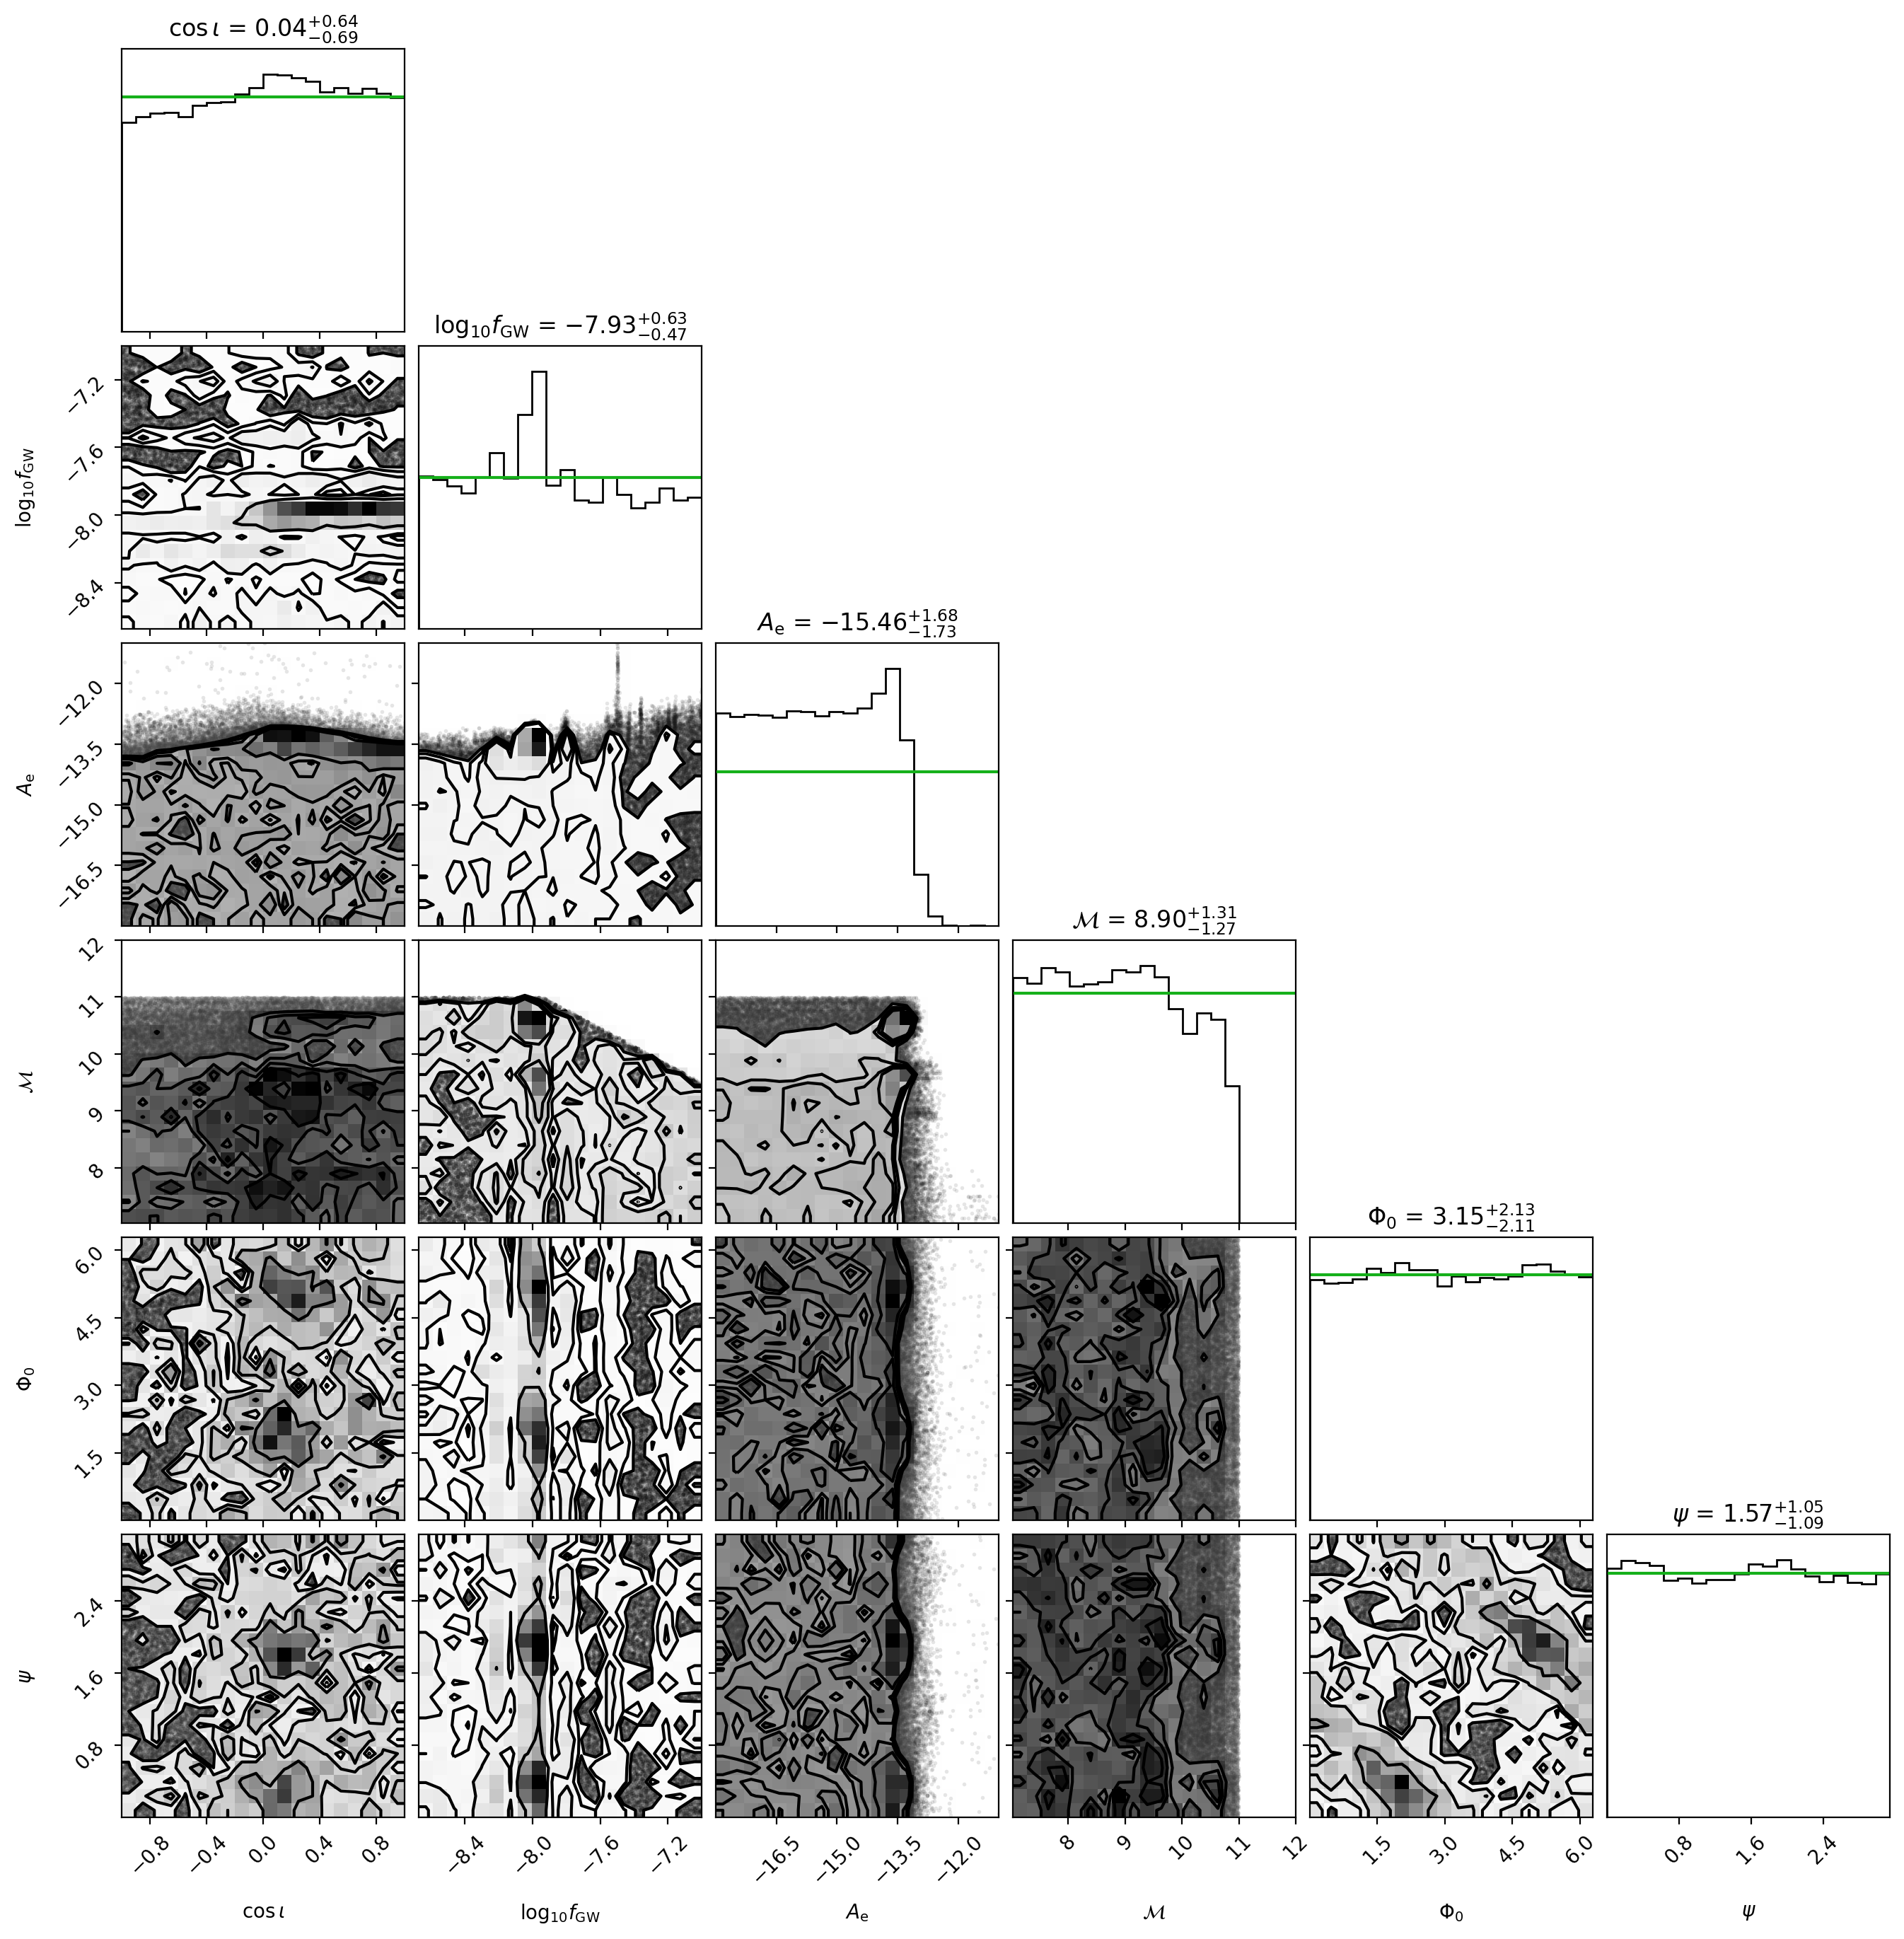

In [7]:
#corner plot of parameters common to all pulsars UNIFORM PRIOR

corner_mask = [0, 1, 2, 3, 4, 5, 6, 7]
labels = [r"$\cos \iota$", r"$\log_{10} f_{\rm GW}$",r"$A_{\rm e}$", r"$\cal M$", r"$\Phi_0$",r"$\psi$"]
par_keys = [ "0_cos_inc", "0_log10_fgw", "0_log10_h", "0_log10_mc", "0_phase0", "0_psi"]

burnin = 10
thin = 1000

#set ranges
ranges = [ (-1,1), (np.min(samples_cold[0][burnin::thin,3]),np.max(samples_cold[0][burnin::thin,3])),(np.min(samples_cold[0][burnin::thin,4]),-11), (np.min(samples_cold[0][burnin::thin,5]),12), (0,2*np.pi), (0,np.pi) ]

#set burnin and thinning

print("fGW",np.min(samples_cold[0][burnin::thin,3]))
truth = [xxx[key] for key in par_keys]

samples_cold_detect = np.vstack((
                          samples_cold[0][burnin::thin,1],
                          samples_cold[0][burnin::thin,3],
                          samples_cold[0][burnin::thin,4],
                          samples_cold[0][burnin::thin,5],
                          samples_cold[0][burnin::thin,6],
                          samples_cold[0][burnin::thin,7])).T

fig = corner.corner(samples_cold_detect, labels=labels, show_titles=True, # quantiles=[0.16, 0.5, 0.84],
                     range=ranges, hist_kwargs={"density":True}) #truths=truth,

#plot priors over 1D posteriors
for i, ax in enumerate(fig.axes):
    if i==0:#(len(labels)+1): #cos inc and cos theta
        Xs = np.linspace(-1,1)
        ax.plot(Xs, Xs*0+1/2, color="xkcd:green")
    elif i==1*(len(labels)+1): #log10_fgw
        Xs = np.linspace(-9, -7)
        # Y = plot_Gaussian(Xs,np.log10(1.13e-8),1)
        # ax.plot(Xs,Y, color='xkcd:green')
        ax.plot(Xs, Xs*0+1/(np.max(samples_cold[0][burnin::thin,3]) - np.min(samples_cold[0][burnin::thin,3])), color="xkcd:green")
    elif i==2*(len(labels)+1): #log10_A
        #Xs = np.linspace(10**-18, 10**-11)     #amplitude
        Xs = np.linspace(np.min(samples_cold[0][burnin::thin,4]), -11)#np.max(samples_cold[0][burnin::thin,4]))
        ax.plot(Xs,Xs*0+(1/(np.max(samples_cold[0][burnin::thin,4]) - np.min(samples_cold[0][burnin::thin,4]))), color="xkcd:green")
        #ax.plot(Xs, Xs*0+1/7, color="xkcd:green")
    elif i==3*(len(labels)+1): #log10_M_ch
        Xs = np.linspace(np.min(samples_cold[0][burnin::thin,5]), 12)#np.max(samples_cold[0][burnin::thin,5]))
        # Y=plot_Gaussian(Xs,9.86,1)
        # ax.plot(Xs,Y, color='xkcd:green')
        ax.plot(Xs,Xs*0+(1/(np.max(samples_cold[0][burnin::thin,5]) - np.min(samples_cold[0][burnin::thin,5]))), color="xkcd:green")
        #ax.plot(Xs, 10**(Xs*0+1/3), color="xkcd:green")
    elif i==4*(len(labels)+1): #gwphi and phase0
        Xs = np.linspace(0,2*np.pi)
        ax.plot(Xs, Xs*0+1/(2*np.pi), color="xkcd:green")
    elif i==5*(len(labels)+1): #psi
        Xs = np.linspace(0,np.pi)
        ax.plot(Xs, Xs*0+1/np.pi, color="xkcd:green")
        
#fig.suptitle('MDC__SMBHB_Source_and_GWB_G2D2_targetedfreq_detection (Without dL)', fontsize = 25);

[6.665324702494525e-01, -8.43, -13.668773493298787, 9.63, 0.24434609527920614, 1.1187560505283651]
hamp [6.7179999e-16 1.0285810e-15 2.1662502e-14 ... 2.4901579e-17 2.0647750e-17
 3.5672995e-18]
freq [1.0179527e-08 9.6835668e-09 9.6835668e-09 ... 2.9219674e-08 2.4477134e-09
 5.1453091e-09]
mc [9.0752389e+09 6.8328122e+08 6.8328122e+08 ... 2.7202537e+09 1.3247421e+10
 5.9333530e+10]
Length of logdL 99999999
required values 8.796526 9.683567e-09 683281200.0 5.2984604e-14
dL min 74.646
dL max 76.15400000000001
10**log10_d_L [1.6405094e+04 1.3913013e+02 6.6061893e+00 ... 1.2000776e+05 3.8769484e+05
 4.4813136e+07]
min 10**log10_d_L 3.7675112e-05
max 10**log10_d_L 625930240.0
d_L_mask [     883      951     2083 ... 99996771 99997076 99998157]
Sample shape (99999999, 9)
dL_mask length 140042
6
mc 7.0301323 9.973271


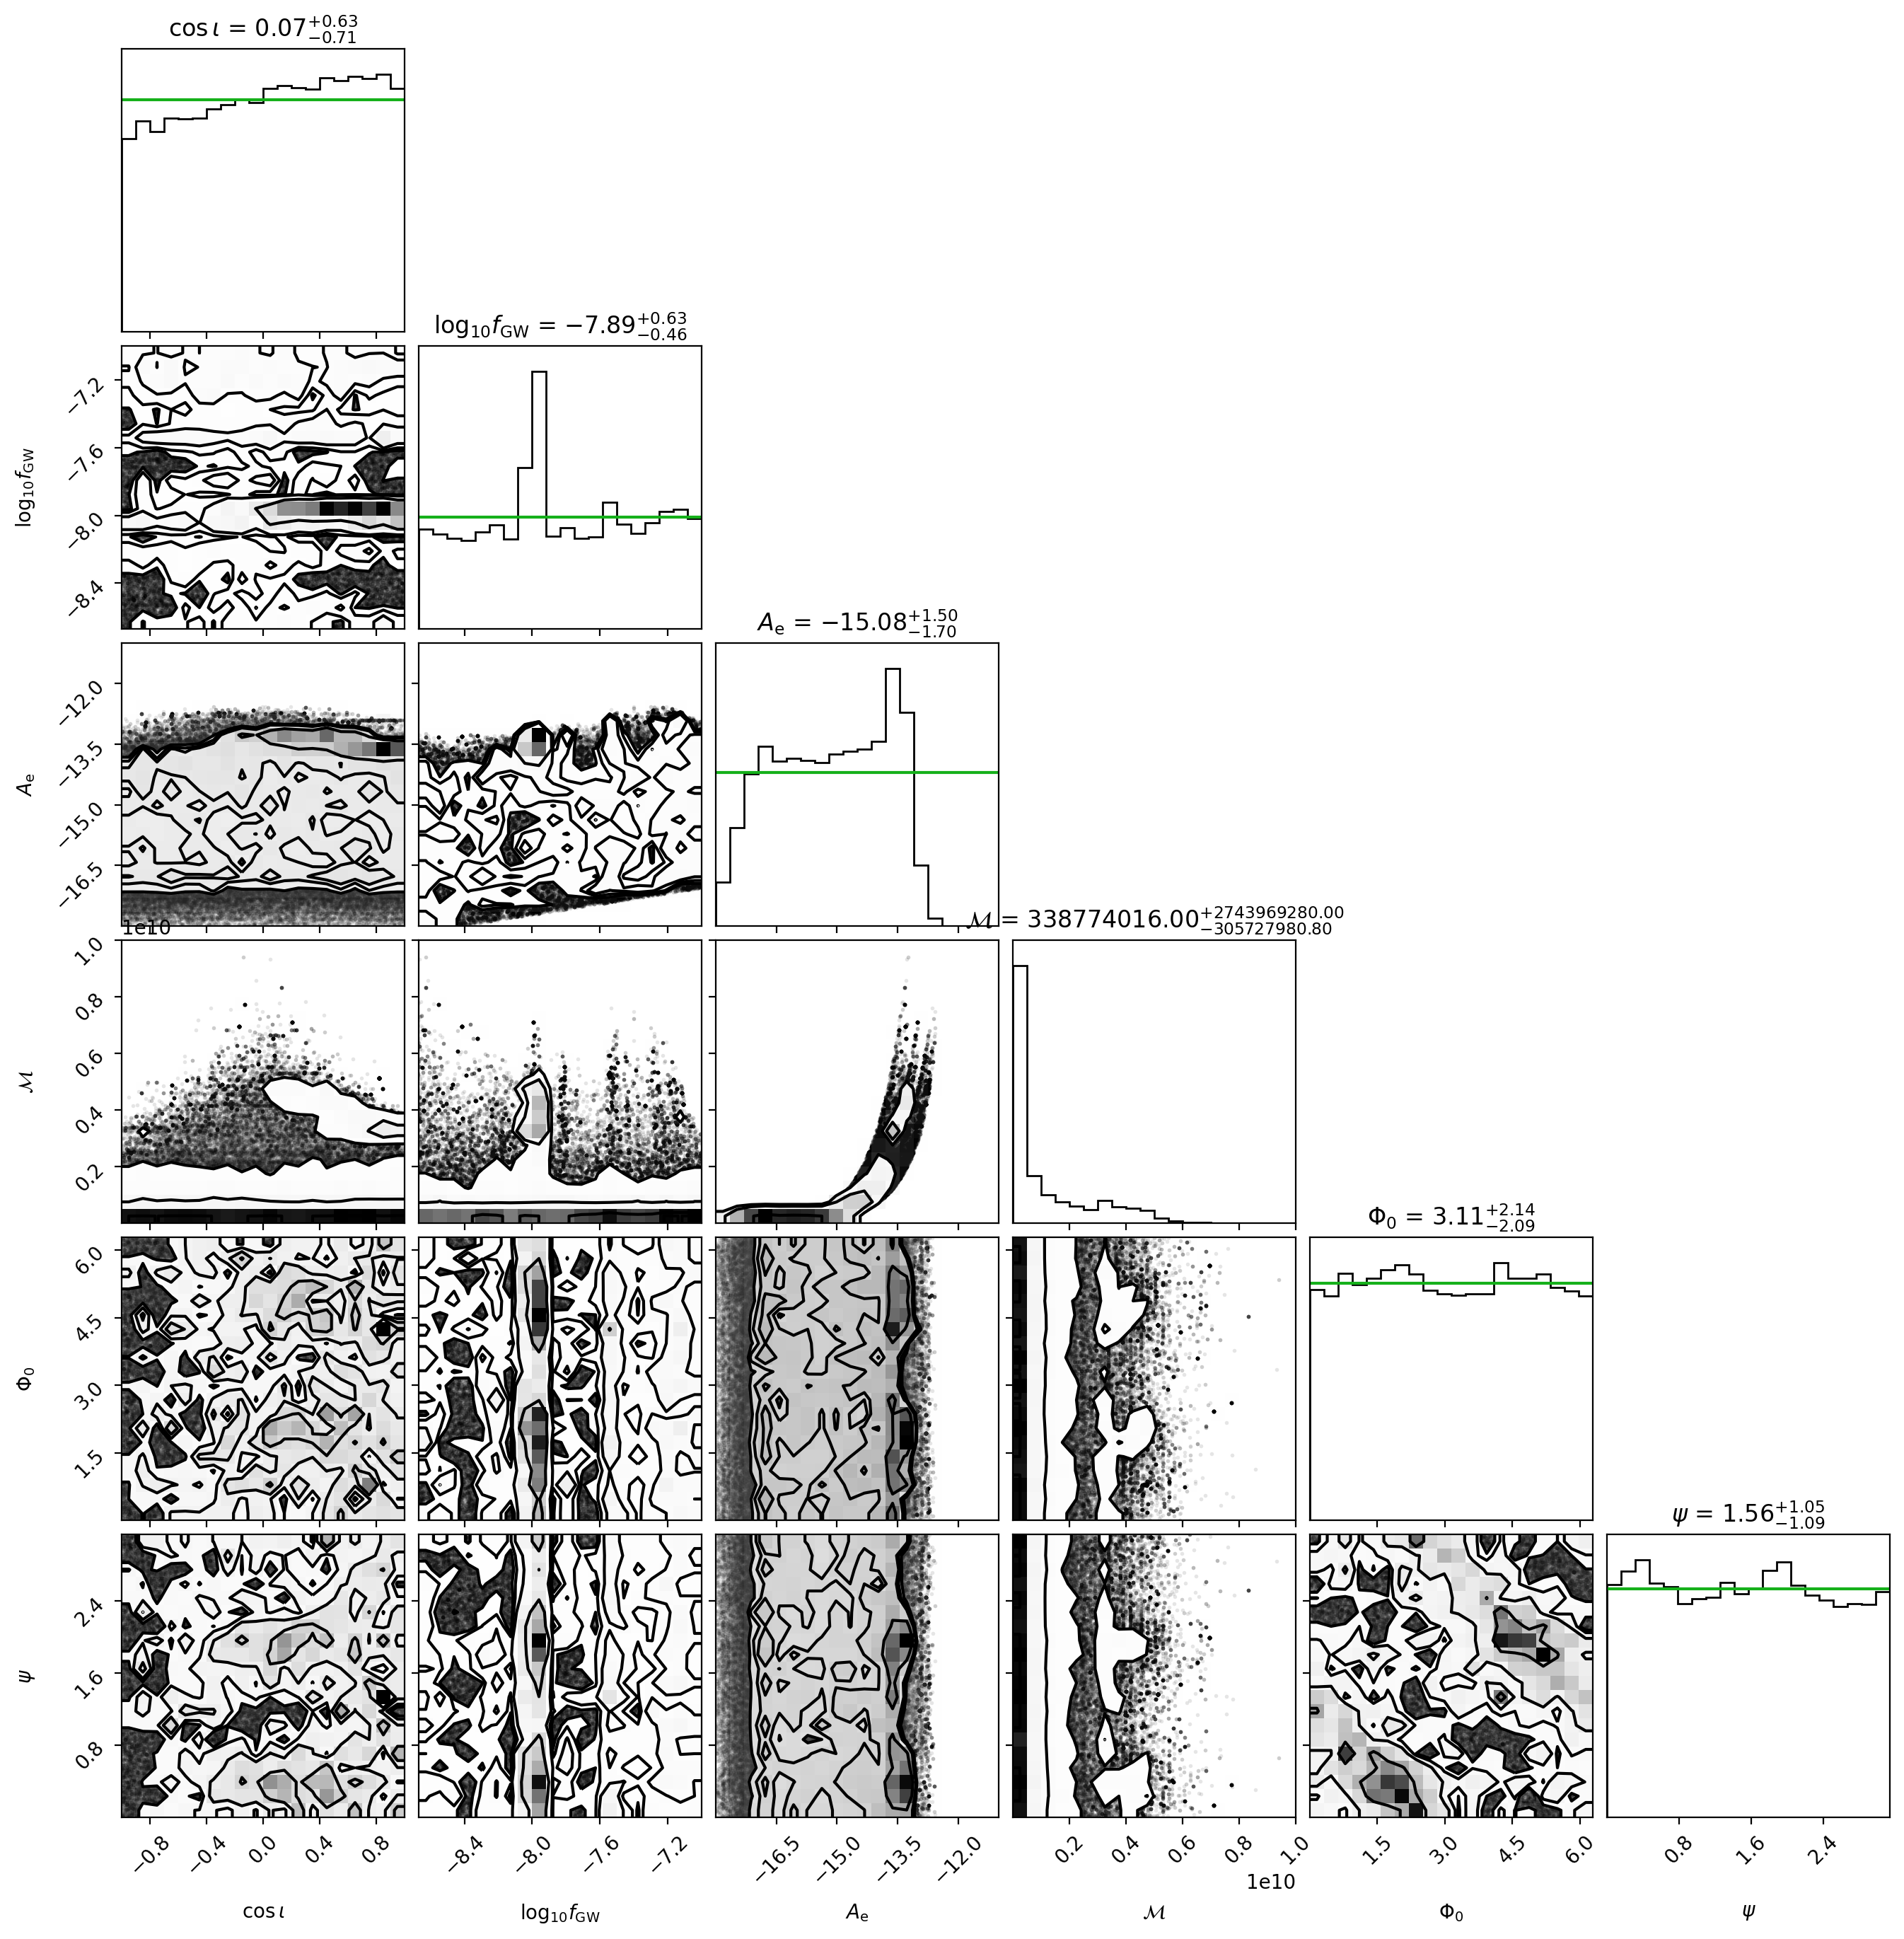

In [8]:
#corner plot of parameters common to all pulsars (Contains Luminosity distance)
corner_mask = [0, 1, 2, 3, 4, 5, 6, 7]
labels = [r"$\cos \iota$", r"$\log_{10} f_{\rm GW}$",r"$A_{\rm e}$", r"$\cal M$", r"$\Phi_0$",r"$\psi$"]
par_keys = [ "0_cos_inc",  "0_log10_fgw","0_log10_h", "0_log10_mc", "0_phase0", "0_psi"]

truth = [xxx[key] for key in par_keys]
print(truth)


#set burnin and thinning

burnin = 1
thin = 1

#set ranges
#ranges = [(-1,1),(np.min(samples_cold[0][burnin::thin,4]),np.max(samples_cold[0][burnin::thin,4])) , (np.min(samples_cold[0][burnin::thin,5]),np.max(samples_cold[0][burnin::thin,5])), (0,2*np.pi), (0,np.pi)]

#ranges = [ (-1,1), (-9,-7),(-18,-11), (7,12), (0,2*np.pi), (0,np.pi) ]

ranges = [ (-1,1), (-8.67,-7),(-18,-11), (10**7,10**10), (0,2*np.pi), (0,np.pi) ]


megaparsec = 3.086e+22 #meter
speed_of_light = 299792458.0 #m/s
T_sun = 1.327124400e20 / speed_of_light**3 #G*M_sun/c^3 = R_sun/c-->Sun time

############################################################################
h_amp = 10**samples_cold[0][burnin::thin,4]
fff = 10**samples_cold[0][burnin::thin,3]
mmm = 10**samples_cold[0][burnin::thin,5]

print('hamp',h_amp)
print('freq',fff)
print('mc',mmm)

log10_d_L = np.log10(2 * (mmm*T_sun)**(5/3) * (np.pi*fff)**(2/3) / h_amp *speed_of_light/megaparsec)
print("Length of logdL", len(log10_d_L))
print("required values",np.max(log10_d_L), fff[1000], mmm[1000], h_amp[1000] )
#####################################
d_L_percent_tolerance = 1.0
#####################################

d_L_min = target_d_L*(1-d_L_percent_tolerance/100)
d_L_max = target_d_L*(1+d_L_percent_tolerance/100)
print("dL min",d_L_min)
print("dL max",d_L_max)
print("10**log10_d_L",10**log10_d_L)
print("min 10**log10_d_L",np.min(10**log10_d_L))
print("max 10**log10_d_L",np.max(10**log10_d_L))

d_L_mask = np.where((10**log10_d_L>=d_L_min) & (10**log10_d_L<=d_L_max))[0]
print("d_L_mask",d_L_mask)


samples2plot = np.concatenate((samples_cold[0][burnin::thin,corner_mask], np.array([log10_d_L,]).T), axis=1)

print("Sample shape", samples2plot.shape)
print("dL_mask length", len(d_L_mask))
print(len(ranges))

samples2plot_detect = np.vstack((
                          samples2plot[d_L_mask,1],
                          samples2plot[d_L_mask,3],
                          samples2plot[d_L_mask,4],
                          10**samples2plot[d_L_mask,5],
                          samples2plot[d_L_mask,6],
                          samples2plot[d_L_mask,7])).T

print("mc", np.min(samples2plot[d_L_mask,5]), np.max(samples2plot[d_L_mask,5]))
fig = corner.corner(samples2plot_detect,
                    labels=labels,
                    show_titles=True, 
                    range=ranges, hist_kwargs={"density":True},truth_color='red') #truths=truth,

#quantiles=[0.16, 0.5, 0.84],

#plot priors over 1D posteriors
for i, ax in enumerate(fig.axes):
    if i==0:#(len(labels)+1): #cos inc and cos theta
        Xs = np.linspace(-1,1)
        ax.plot(Xs, Xs*0+1/2, color="xkcd:green")
    elif i==1*(len(labels)+1): #log10_fgw
        Xs = np.linspace(-9, -7)
        # Y = plot_Gaussian(Xs,np.log10(1.13e-8),1)
        # ax.plot(Xs,Y, color='xkcd:green')
        ax.plot(Xs, Xs*0+1/(np.max(samples2plot[d_L_mask,3]) - np.min(samples2plot[d_L_mask,3])), color="xkcd:green")
    elif i==2*(len(labels)+1): #log10_A
        #Xs = np.linspace(10**-18, 10**-11)     #amplitude
        Xs = np.linspace(np.min(samples2plot[d_L_mask,4]), -11)#np.max(samples_cold[0][burnin::thin,4]))
        ax.plot(Xs,Xs*0+(1/(np.max(samples2plot[d_L_mask,4]) - np.min(samples2plot[d_L_mask,4]))), color="xkcd:green")
        #ax.plot(Xs, Xs*0+1/7, color="xkcd:green")
    elif i==3*(len(labels)+1): #log10_M_ch
        Xs = np.linspace(np.min(samples2plot[d_L_mask,5]), 12)#np.max(samples_cold[0][burnin::thin,5]))
        # Y=plot_Gaussian(Xs,9.86,1)
        # ax.plot(Xs,Y, color='xkcd:green')
        ax.plot(Xs,Xs*0+(1/(np.max(samples2plot[d_L_mask,5]) - np.min(samples2plot[d_L_mask,5]))), color="xkcd:green")
        #ax.plot(Xs, 10**(Xs*0+1/3), color="xkcd:green")
    elif i==4*(len(labels)+1): #gwphi and phase0
        Xs = np.linspace(0,2*np.pi)
        ax.plot(Xs, Xs*0+1/(2*np.pi), color="xkcd:green")
    elif i==5*(len(labels)+1): #psi
        Xs = np.linspace(0,np.pi)
        ax.plot(Xs, Xs*0+1/np.pi, color="xkcd:green")

7.0301323e+00
9.973271


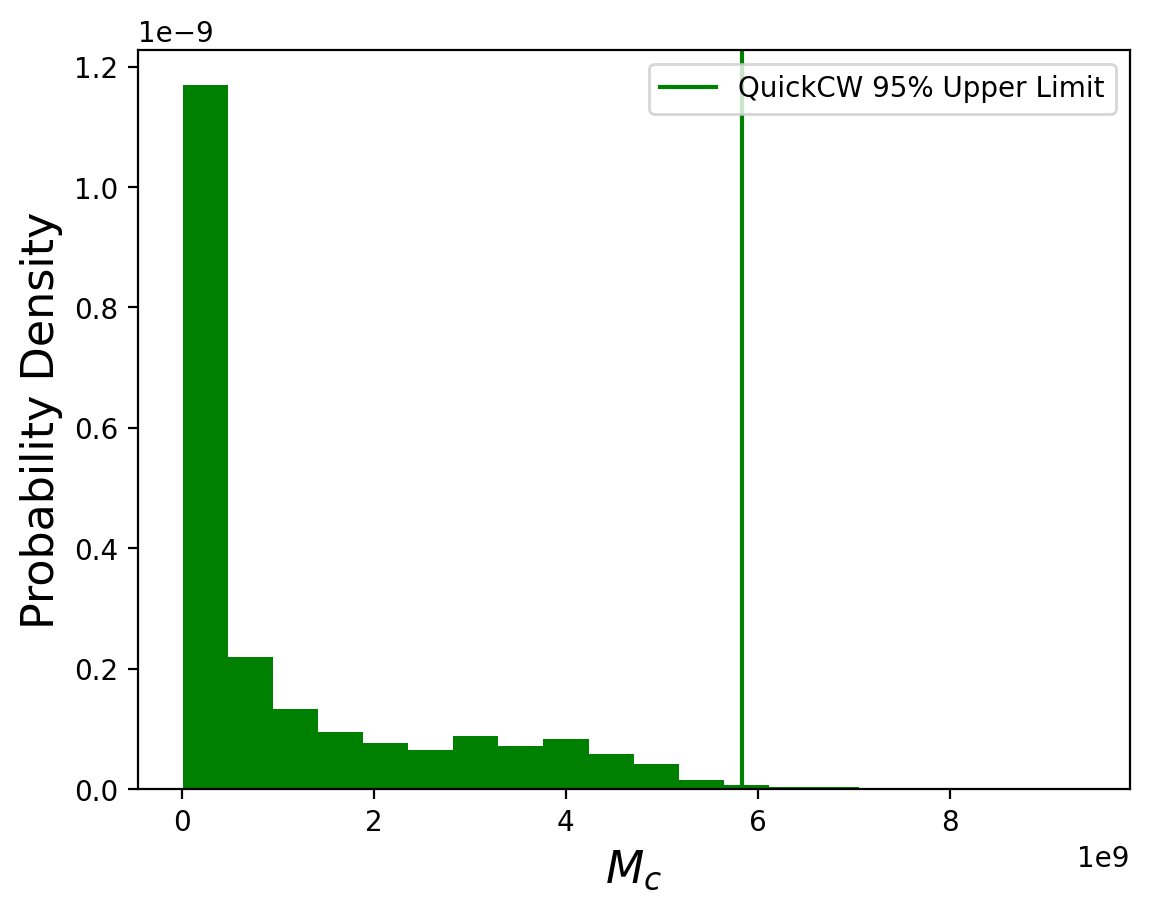

4.401642496
9.64361476599572
9.64361476599572


In [9]:
#dL Mc Upper limit

logMcmin_dL = np.min(samples2plot[d_L_mask,5])
logMcmax_dL = np.max(samples2plot[d_L_mask,5])

#print(samples2plot[d_L_mask,5])
#print(np.power(10,samples2plot[d_L_mask,5]))

print(logMcmin_dL)
print(logMcmax_dL)

plt.hist(np.power(10,samples2plot[d_L_mask,5]), bins=20, density=True,color='green')
#plt.hist(bjorn_UL, bins=20, density=True,color='blue', alpha = 0.5)
plt.axvline(x = 5838170214.399944,color='green',label= "QuickCW 95% Upper Limit")
#plt.axvline(x = 5539651847.030904,color='blue',label= "Enterprise 95% Upper Limit")
#plt.title("NGC3115 Upper Limit Mc histogram (with dL masking)", y=1.05)
plt.xlabel("$M_c$",fontsize = 16)
plt.ylabel("Probability Density", fontsize = 16)
plt.legend(loc='upper right')
plt.show()

x = np.quantile(np.power(10,samples2plot[d_L_mask,5]), 0.95)
print(x/1e9)
print(np.log10(x))
#y = np.quantile(bjorn_UL, 0.95)
#print(y/1e9)
print(np.log10(x))

In [10]:
print(np.max(samples2plot[d_L_mask,4]))

-12.5669775


In [11]:
fmax=np.max(10**samples2plot[d_L_mask,3])
fmin=np.min(10**samples2plot[d_L_mask,3])
print(fmin)

T = 2.118325e-09
bins = fmax-fmin
print(bins/T)
print(fmax,fmin)
print(T*47)

2.118325e-09
46.20514011564984
9.999583e-08 2.118325e-09
9.9561275e-08


In [12]:
print(samples2plot[d_L_mask,3][10])

-8.639214


In [13]:
T = 2.118325e-09  # Step size for vals
fmax = np.max(10 ** samples2plot[d_L_mask, 3])  # Maximum value from your data
fmin = np.min(10 ** samples2plot[d_L_mask, 3])  # Minimum value from your data

# Create a list of values starting from fmin and incrementing by T until fmax
vals = []
while fmin < fmax:
    vals.append(fmin)
    fmin += T

# Print the length of vals for debugging (optional)
#print(len(vals) - 1)
#print(vals[0],vals[1])
# Find the indices in samples2plot[d_L_mask, 3] that are between consecutive values in vals
indices = []
inc = 0
for i, value in enumerate(10 ** samples2plot[d_L_mask, 3]):
    # Make sure that inc + 1 is a valid index in vals
    if inc < len(vals)-1:
        #print(inc)
        if vals[inc] >= value and value <=vals[inc+1]:
            #print(value)
            indices.append(i)
        inc += 1  # Increment inc only when condition is met
    else:
        break  # Exit the loop once you've processed all values in vals

# Output the indices
#print(indices)


In [14]:
#WORKS PROPERLY (DONT DELETE!!)
def calculate_mc(inc):
    
    
    T = 2.118325e-09
    fmax=np.max(10**samples2plot[d_L_mask,3])
    fmin=np.min(10**samples2plot[d_L_mask,3])


    vals = []
    while fmin < fmax:
        #print(fmin)  # Round to 1 decimal place for better formatting
        vals.append(fmin)
        fmin += T

    indices=[]
    for i, value in enumerate(10**samples2plot[d_L_mask,3]):
        #print("at inc "+str(inc) +" I have " + str(i))
        if  value >= vals[inc] and value <=vals[inc+1]:
            #print ("MY VALUE "+str(value)+" is between "+str(vals[inc])+" and "+str(vals[inc+1]))
            indices.append(i)
        #inc += 1  # Increment inc only when condition is met 
    #print(indices)


    data_list= [10**samples2plot[d_L_mask[i],5] for i in indices]
    #print(len(data_list))
    return data_list


In [15]:
#WORKS PROPERLY (DONT DELETE!!)

arr = []

for i in range(0,46):
    arr.append(calculate_mc(i))

arr_len=[]
for i in range(0,46):
    arr_len.append(len(arr[i]))
#print(arr)
print(arr_len)
#plt.plot(fGW_vals,arr_len)




[20923, 12887, 8770, 19649, 7100, 4695, 4697, 3171, 3184, 2832, 2723, 2603, 3141, 3211, 2214, 1786, 2105, 1633, 1543, 1581, 1541, 1410, 1290, 1514, 1550, 1207, 1534, 1287, 1285, 1203, 1223, 1532, 1109, 1008, 925, 1255, 985, 875, 1010, 779, 847, 843, 849, 699, 759, 891]


In [16]:
UL = []


for i in range(0,46):
    x = np.quantile(arr[i], 0.95)
    UL.append(x)
    
print(UL)
print(np.log10(UL))
print(len(UL))




[4077325697.498522, 3408632535.7245517, 3167580447.2661185, 4861149391.475976, 4610983454.40233, 3784210384.306069, 4998828583.693569, 2548190429.1180625, 2403526332.8211284, 2007921697.747145, 2332612906.387711, 2194585884.9492836, 4590636059.714462, 5134699381.584373, 3081220660.0461607, 3668571552.2045836, 4176095814.8579764, 2294510856.3853617, 3477173707.159619, 2501618131.252926, 4147472799.3953233, 2339368808.179925, 3676388620.948617, 5327089835.591904, 4709017711.311884, 4631888889.676282, 3695715051.5567994, 3407309430.923764, 3722356354.818322, 3564167322.367316, 4605407769.43897, 4200996483.617967, 4744936782.186287, 2788775725.1754575, 2598880669.273216, 4595366321.078329, 3389730622.2241, 2307498352.349208, 2584717144.66741, 3087858580.3906317, 1908168666.9822464, 2070686850.7641118, 2468229182.535794, 2032163295.2214062, 2011540521.7789862, 2096022180.0257487]
[9.6103754  9.53258019 9.50072765 9.68673897 9.66379356 9.57797527
 9.69886824 9.40623188 9.38084888 9.30274677 

In [17]:
def UL_error_calc(n):
    global arr
    global UL
    counts, bin_edges, _ =plt.hist(arr[n], density=True)
    plt.axvline(x=UL[n],color='black')#,label= "15yr Upper Limit = 2.89e+10")
    #plt.axvline(x = 1.34e+09,color='red',label= "12.5yr Upper Limit = 1.34e+09 ")
    
    bin_index = np.digitize(UL[n], bin_edges) - 1  # -1 because digitize returns index starting from 1
    #print(bin_index)
    # Get the corresponding y value (the count in the appropriate bin)
    
    if bin_index < len(counts):
        y_value = counts[bin_index]
        #print(y_value)
    else:
        #print(f"Warning: bin_index {bin_index} is out of bounds.")
        y_value = 0  # Set to a default value or handle as needed
    
    '''
    y_value = counts[bin_index]
    #print('y_value',y_value.shape)
    '''
    sigma = np.sqrt((.95*.05)/len(arr[n]))/y_value
    #print(len(arr[n]))
    return sigma

[43543157.63840035, 43938587.28924545, 29677847.209265452, 6933425.797643895, 24072938.786733277, 85625220.60352418, 39880115.84378917, 106206754.43584311, 60827000.05361993, 43219323.95173039, 49368582.02439482, 136590409.8941544, 152060488.7323172, 18863040.686978083, 76986052.20470987, 149963889.1040039, 68754655.23052444, 193258050.08403602, 84049800.8168538, 49034688.76127972, 53031848.10760629, 58214055.50697968, 317416254.8558007, 157541246.45050755, 72131902.3180144, 108684141.71055765, 143091373.15739205, 62975969.92246759, 263243444.40092435, 105442568.85903583, 83562496.07609968, 149339724.90065497, 52431330.110070705, 69510371.80296968, 128287114.2567517, 38950212.71539897, 197053677.5908519, 82512858.008567, 105947421.42871127, 301722846.2321498, 68596544.79616569, 335728267.7419481, 61432129.64545126, 54112707.391323194, 37586914.87560996, 227634475.41792777]
46


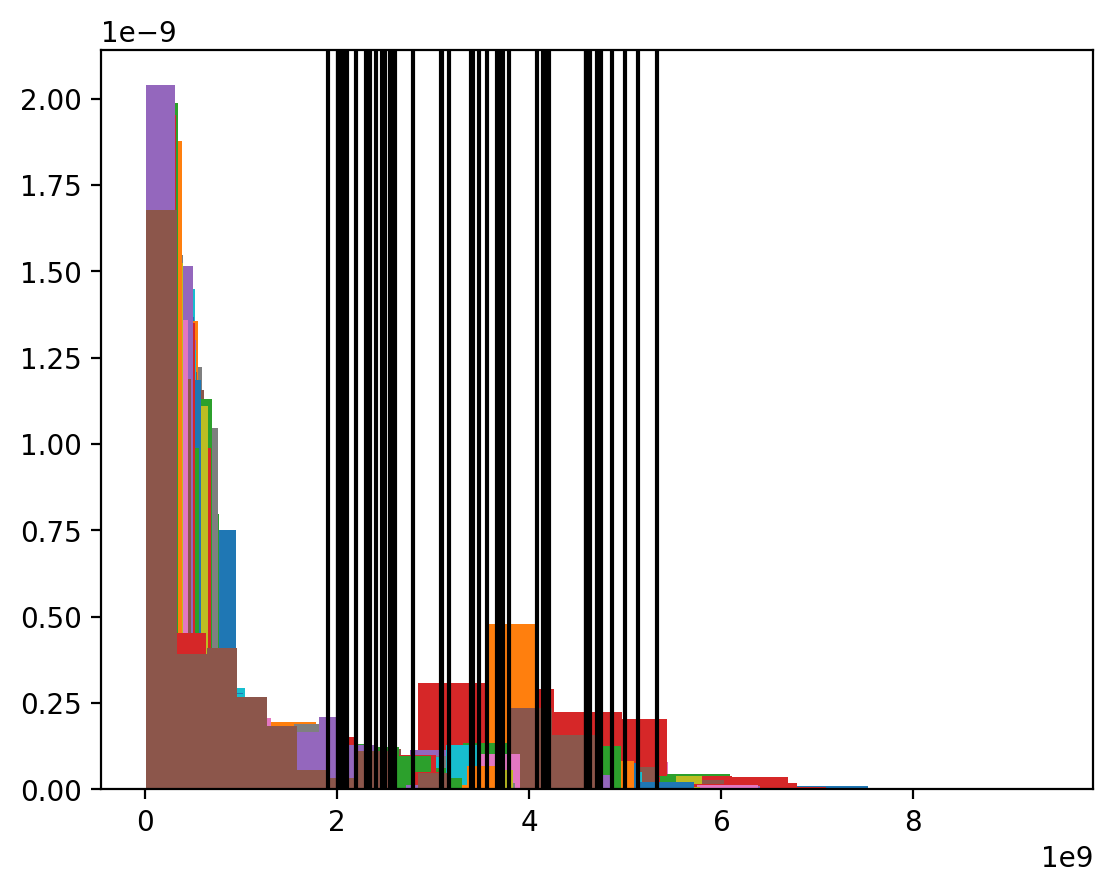

In [18]:
sigma_val = []

for i in range(0,46):
    sigma_val.append(UL_error_calc(i))

print(sigma_val)
print(len(sigma_val))



In [19]:

T = 2.118325e-09
fmax=np.max(10**samples2plot[d_L_mask,3])
fmin=np.min(10**samples2plot[d_L_mask,3])


vals = []
while fmin < fmax:
    #print(fmin)  # Round to 1 decimal place for better formatting
    vals.append(fmin)
    fmin += T
    
print(vals)
print(len(vals))


[2.118325e-09, 4.236650070910033e-09, 6.354975070910033e-09, 8.473300070910034e-09, 1.0591625070910034e-08, 1.2709950070910035e-08, 1.4828275070910035e-08, 1.6946600070910036e-08, 1.9064925070910036e-08, 2.1183250070910037e-08, 2.3301575070910037e-08, 2.5419900070910038e-08, 2.753822507091004e-08, 2.965655007091004e-08, 3.177487507091004e-08, 3.389320007091004e-08, 3.601152507091004e-08, 3.812985007091004e-08, 4.024817507091004e-08, 4.236650007091004e-08, 4.448482507091004e-08, 4.6603150070910043e-08, 4.8721475070910044e-08, 5.0839800070910045e-08, 5.2958125070910045e-08, 5.5076450070910046e-08, 5.7194775070910046e-08, 5.9313100070910047e-08, 6.143142507091005e-08, 6.354975007091004e-08, 6.566807507091004e-08, 6.778640007091003e-08, 6.990472507091002e-08, 7.202305007091002e-08, 7.414137507091001e-08, 7.625970007091e-08, 7.837802507091e-08, 8.049635007090999e-08, 8.261467507090999e-08, 8.473300007090998e-08, 8.685132507090997e-08, 8.896965007090997e-08, 9.108797507090996e-08, 9.32063000

In [20]:
print(np.log10(fmin))

-6.992766170630077


In [21]:
UL_vals = [4077325697.498522, 3408632535.7245517, 3167580447.2661185, 
           4861149391.475976, 4610983454.40233, 3784210384.306069, 4998828583.693569, 
           2548190429.1180625, 2403526332.8211284, 2007921697.747145, 2332612906.387711, 
           2194585884.9492836, 4590636059.714462, 5134699381.584373, 3081220660.0461607, 3668571552.2045836, 
           4176095814.8579764, 2294510856.3853617, 3477173707.159619, 2501618131.252926, 4147472799.3953233, 
           2339368808.179925, 3676388620.948617, 5327089835.591904, 4709017711.311884, 4631888889.676282, 
           3695715051.5567994, 3407309430.923764, 3722356354.818322, 3564167322.367316, 4605407769.43897,
           4200996483.617967, 4744936782.186287, 2788775725.1754575, 2598880669.273216, 4595366321.078329,
           3389730622.2241, 2307498352.349208, 2584717144.66741, 3087858580.3906317, 1908168666.9822464, 
           2070686850.7641118, 2468229182.535794, 2032163295.2214062, 2011540521.7789862, 2096022180.0257487]
           
           

fGW_vals = [ 4.236650070910033e-09, 6.354975070910033e-09, 8.473300070910034e-09, 
            1.0591625070910034e-08, 1.2709950070910035e-08, 1.4828275070910035e-08, 1.6946600070910036e-08, 
            1.9064925070910036e-08, 2.1183250070910037e-08, 2.3301575070910037e-08, 2.5419900070910038e-08, 
            2.753822507091004e-08, 2.965655007091004e-08, 3.177487507091004e-08, 3.389320007091004e-08, 
            3.601152507091004e-08, 3.812985007091004e-08, 4.024817507091004e-08, 4.236650007091004e-08, 
            4.448482507091004e-08, 4.6603150070910043e-08, 4.8721475070910044e-08, 5.0839800070910045e-08, 
            5.2958125070910045e-08, 5.5076450070910046e-08, 5.7194775070910046e-08, 5.9313100070910047e-08,
            6.143142507091005e-08, 6.354975007091004e-08, 6.566807507091004e-08, 6.778640007091003e-08, 
            6.990472507091002e-08, 7.202305007091002e-08, 7.414137507091001e-08, 7.625970007091e-08, 
            7.837802507091e-08, 8.049635007090999e-08, 8.261467507090999e-08, 8.473300007090998e-08, 
            8.685132507090997e-08, 8.896965007090997e-08, 9.108797507090996e-08, 9.320630007090996e-08, 
            9.532462507090995e-08, 9.744295007090994e-08, 9.956127507090994e-08]

UL_error = [43543157.63840035, 43938587.28924545, 29677847.209265452, 6933425.797643895, 24072938.786733277, 
            85625220.60352418, 39880115.84378917, 106206754.43584311, 60827000.05361993, 43219323.95173039,
            49368582.02439482, 136590409.8941544, 152060488.7323172, 18863040.686978083, 76986052.20470987, 
            149963889.1040039, 68754655.23052444, 193258050.08403602, 84049800.8168538, 49034688.76127972, 
            53031848.10760629, 58214055.50697968, 317416254.8558007, 157541246.45050755, 72131902.3180144, 
            108684141.71055765, 143091373.15739205, 62975969.92246759, 263243444.40092435, 105442568.85903583, 
            83562496.07609968, 149339724.90065497, 52431330.110070705, 69510371.80296968, 128287114.2567517, 
            38950212.71539897, 197053677.5908519, 82512858.008567, 105947421.42871127, 301722846.2321498, 
            68596544.79616569, 335728267.7419481, 61432129.64545126, 54112707.391323194, 37586914.87560996,
            227634475.41792777]

print((4.236650070910033+6.354975070910033)/2)
print(5.295812570910034-4.236650070910033)

 #2.1179296e-09,
plt.figure(figsize=(8,6))

#plt.scatter(fGW_vals,UL_vals)

fGW_plot = []

for i in fGW_vals:
    fGW_plot.append(i-1.0591625000000002e-09)
    
#print(fGW_plot)

UL_by9 = []
for i in UL_vals:
    UL_by9.append(i/1e9)

ULerr_by9 = []
for i in UL_error:
    ULerr_by9.append(i/1e9)
    
print(np.log10(ULerr_by9))




#plt.hist(arr_len, bins=30)#, cmap='Blues')
#print(arr_len)
#print(UL_by9)
'''
plt.errorbar(np.log10(fGW_plot),UL_by9, yerr=(ULerr_by9), fmt='o', color='b', 
             ecolor='b', elinewidth=2, capsize=3, capthick=2,linestyle='-')
             
plt.ticklabel_format(style='sci', axis='both', scilimits=(0,0))
plt.xlabel('$log_{10}(f_{GW})$', fontsize = 20)
plt.ylabel('$log_{10}(M_c)$', fontsize = 20)
#plt.xlim(np.min(vals), np.max(vals))
#plt.title("$M_c$ upper limit vs $f_{GW}$ plot with 47 bins")
'''

5.295812570910034
1.0591625000000002
[-1.36108008 -1.35715391 -1.52756761 -2.15905213 -1.61847089 -1.0673983
 -1.39924359 -0.97384786 -1.2159036  -1.36432203 -1.30654935 -0.86457979
 -0.81798362 -1.7243883  -1.11358795 -0.82401331 -1.16269789 -0.71386241
 -1.07546331 -1.30949658 -1.27546324 -1.23497214 -0.49837084 -0.80260572
 -1.14187261 -0.96383382 -0.84438655 -1.20082514 -0.57964244 -0.97698402
 -1.0779886  -0.82582465 -1.28040912 -1.15795039 -0.89181696 -1.40949017
 -0.70541546 -1.08347837 -0.97490961 -0.5203918  -1.16369776 -0.47401209
 -1.21160443 -1.26670074 -1.42496332 -0.64276196]


'\nplt.errorbar(np.log10(fGW_plot),UL_by9, yerr=(ULerr_by9), fmt=\'o\', color=\'b\', \n             ecolor=\'b\', elinewidth=2, capsize=3, capthick=2,linestyle=\'-\')\n             \nplt.ticklabel_format(style=\'sci\', axis=\'both\', scilimits=(0,0))\nplt.xlabel(\'$log_{10}(f_{GW})$\', fontsize = 20)\nplt.ylabel(\'$log_{10}(M_c)$\', fontsize = 20)\n#plt.xlim(np.min(vals), np.max(vals))\n#plt.title("$M_c$ upper limit vs $f_{GW}$ plot with 47 bins")\n'

<Figure size 800x600 with 0 Axes>

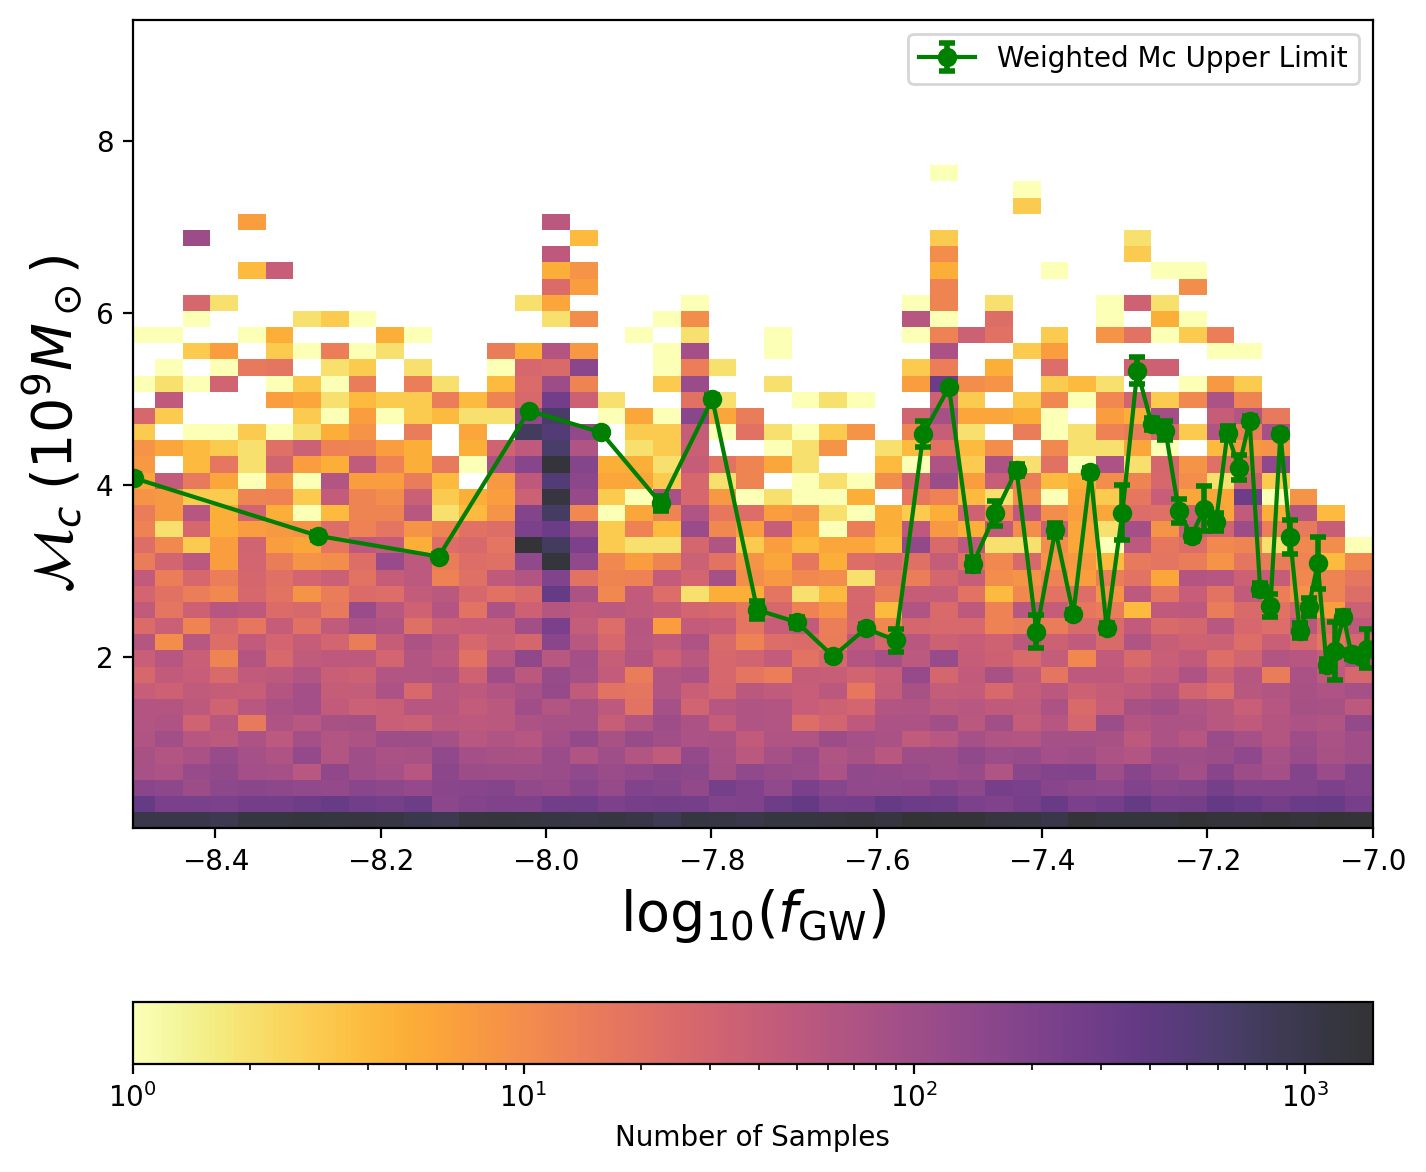

In [23]:


fig, ax = plt.subplots(figsize=(8,7.5))

counts, xbins, ybins, image = ax.hist2d(
    samples2plot[d_L_mask, 3],   # log10(f_GW)
    (10**samples2plot[d_L_mask, 5]) / 1e9,  # Mc in 10^9 Msun
    bins=50,
    norm=colors.LogNorm(),
    alpha=0.8,
    cmap='inferno_r'
)

# Errorbar overlay
ax.errorbar(
    np.log10(fGW_plot), UL_by9, 
    yerr=ULerr_by9, 
    fmt='o', 
    color='g',
    ecolor='green',
    elinewidth=2, 
    capsize=3, 
    capthick=2, 
    linestyle='-', 
    label='Weighted Mc Upper Limit'
)

# Colorbar
cbar = plt.colorbar(image, ax=ax, label='Number of Samples', orientation='horizontal')

# Axis formatting
ax.set_xlim(-8.5, -7)
ax.set_xlabel(r'$\log_{10}(f_{\rm GW})$', fontsize=20)
ax.set_ylabel(r'$\mathcal{M}_c \; (10^9 M_\odot)$', fontsize=20)
ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))  # keep y axis in scientific if needed
ax.legend(fontsize=10)

plt.show()


f [Hz]         Mc [Msun]
1.000000e-08   4.592408e+08
1.011638e-08   4.571202e+08
1.023411e-08   4.550094e+08
1.035322e-08   4.529083e+08
1.047371e-08   4.508170e+08
1.059560e-08   4.487353e+08
1.071891e-08   4.466632e+08
1.084366e-08   4.446007e+08
1.096986e-08   4.425477e+08
1.109752e-08   4.405042e+08
1.122668e-08   4.384701e+08
1.135733e-08   4.364454e+08
1.148951e-08   4.344301e+08
1.162322e-08   4.324240e+08
1.175850e-08   4.304273e+08
1.189534e-08   4.284397e+08
1.203378e-08   4.264613e+08
1.217383e-08   4.244921e+08
1.231551e-08   4.225320e+08
1.245883e-08   4.205809e+08
1.260383e-08   4.186388e+08
1.275051e-08   4.167057e+08
1.289890e-08   4.147815e+08
1.304902e-08   4.128662e+08
1.320088e-08   4.109597e+08
1.335452e-08   4.090621e+08
1.350994e-08   4.071732e+08
1.366716e-08   4.052930e+08
1.382622e-08   4.034215e+08
1.398713e-08   4.015587e+08
1.414991e-08   3.997044e+08
1.431459e-08   3.978587e+08
1.448118e-08   3.960216e+08
1.464971e-08   3.941929e+08
1.482021e-08   3.923727

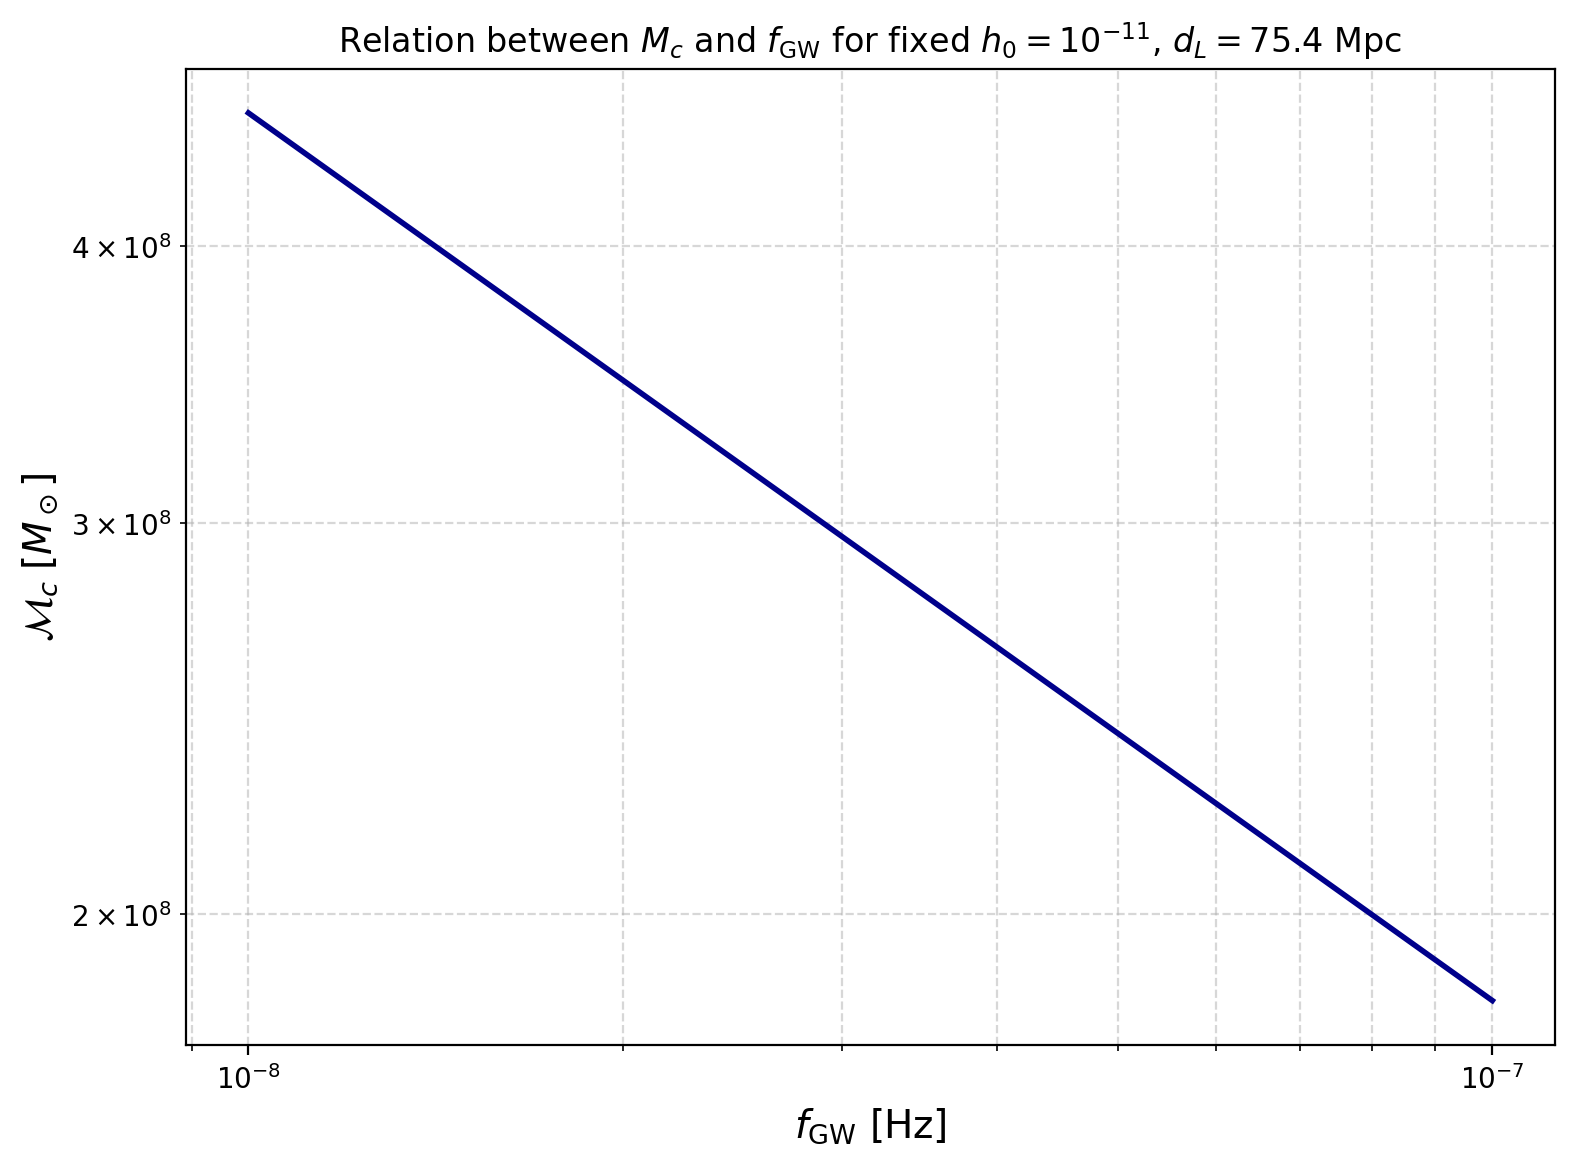

In [32]:

# === Constants ===
megaparsec = 3.086e+22         # meters
speed_of_light = 299792458.0   # m/s
T_sun = 1.327124400e20 / speed_of_light**3  # GM_sun/c^3 in seconds

# === Fixed values ===
h_amp = 1e-15                  # strain amplitude
dL = 75.4 * megaparsec         # luminosity distance in meters

# === Frequency grid (Hz) ===
f_grid = np.logspace(-8, -7, 200)

# === Compute chirp mass (Msun) for each frequency ===
Mc_grid = ( (h_amp * dL) / (2 * speed_of_light * (np.pi * f_grid)**(2/3)) )**(3/5) / T_sun

# === Print some sample values ===
print("f [Hz]         Mc [Msun]")
for f, Mc in zip(f_grid, Mc_grid):
    #print(Mc_grid)
    print(f"{f:.6e}   {Mc:.6e}")

# === Plot ===
plt.figure(figsize=(8,6))
plt.loglog(f_grid, Mc_grid, color='darkblue', lw=2)
plt.xlabel(r'$f_{\rm GW}$ [Hz]', fontsize=14)
plt.ylabel(r'$\mathcal{M}_c \; [M_\odot]$', fontsize=14)
plt.title(r'Relation between $M_c$ and $f_{\rm GW}$ for fixed $h_0=10^{-11}$, $d_L=75.4$ Mpc')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()


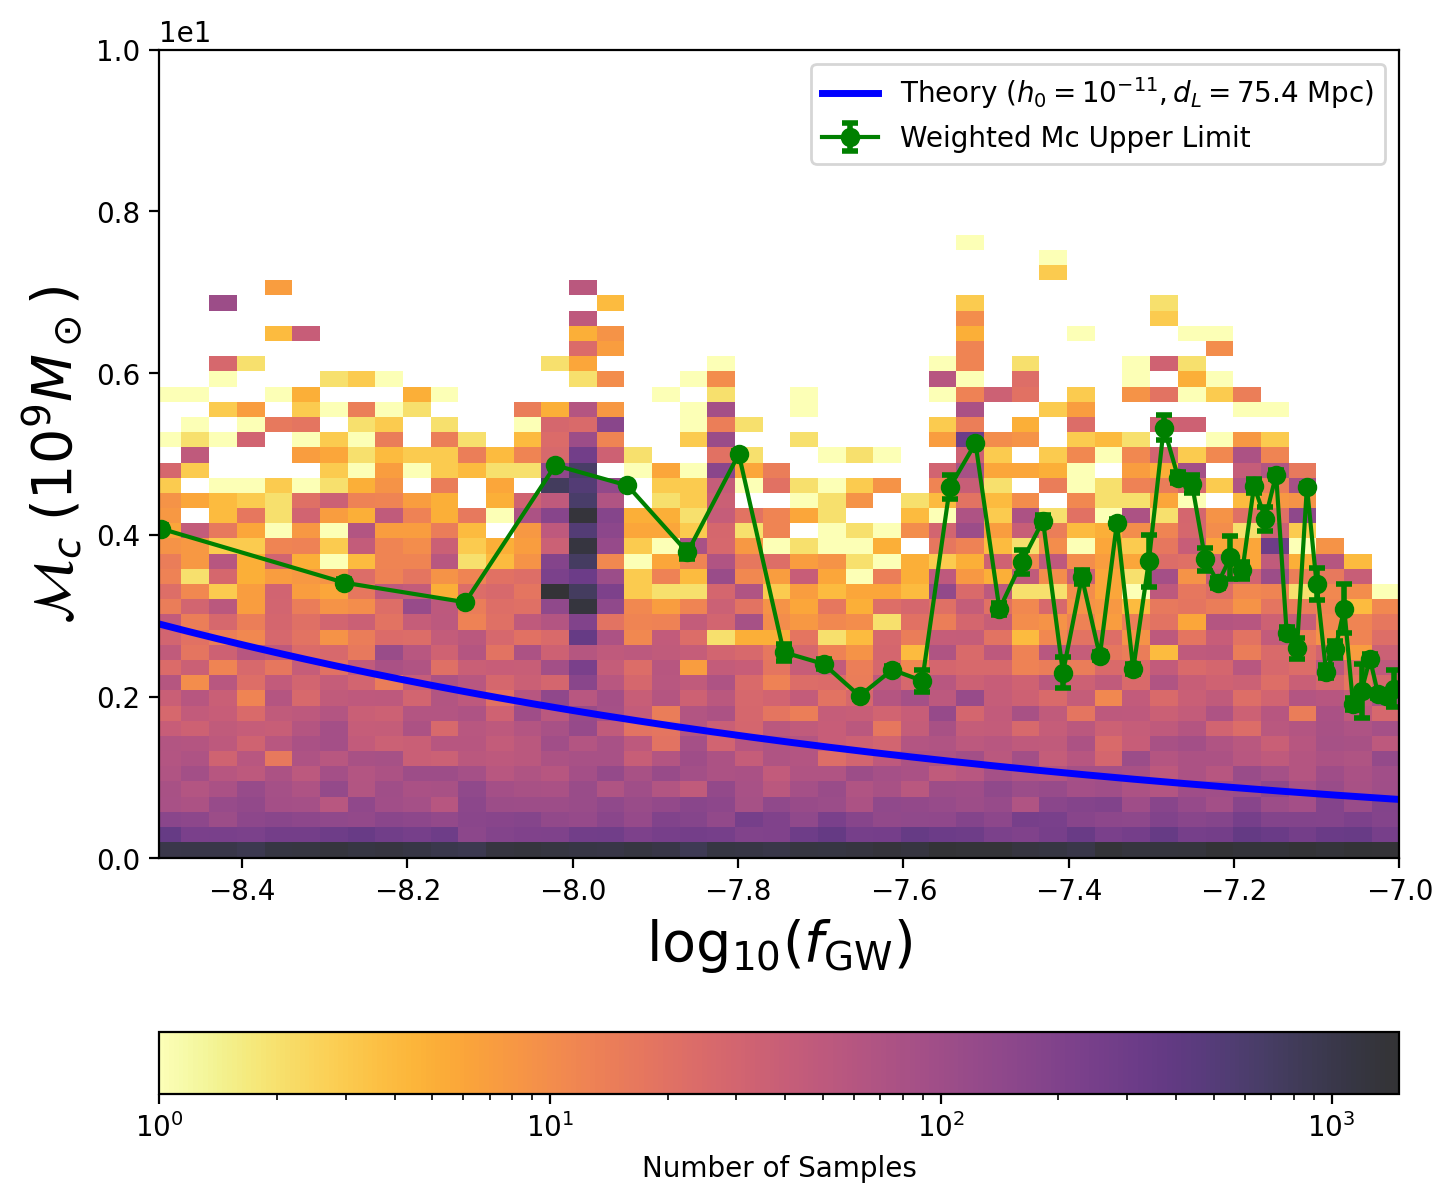

QuickCW Samples (Mc/1e9) [0.68328124 0.12013775 0.49553472 0.49553472 0.49553472 0.49553472
 1.0373958  1.0373958  1.0373958  1.0373958  1.0373958  0.13696574
 0.09005876 0.09005876 0.09005876 0.09005876 0.09005876 0.09005876
 0.09005876 0.09005876]
Theoretical Calculation (Mc/1e9) [3.1771701  3.16780108 3.15845968 3.14914583 3.13985944 3.13060044
 3.12136874 3.11216426 3.10298693 3.09383666 3.08471337 3.07561699
 3.06654742 3.05750461 3.04848846 3.0394989  3.03053584 3.02159922
 3.01268895 3.00380496]
Slopes (Msun per dex):
f=2.51e-09 Hz, Mc=3.18e9 Msun, slope=-2.93e9
f=2.53e-09 Hz, Mc=3.17e9 Msun, slope=-2.92e9
f=2.55e-09 Hz, Mc=3.16e9 Msun, slope=-2.91e9
f=2.57e-09 Hz, Mc=3.15e9 Msun, slope=-2.90e9
f=2.59e-09 Hz, Mc=3.14e9 Msun, slope=-2.89e9


In [35]:
# === Compute theoretical curve of Mc vs f ===
megaparsec = 3.086e+22         # meters
speed_of_light = 299792458.0   # m/s
T_sun = 1.327124400e20 / speed_of_light**3  # GM_sun/c^3 in seconds


h_amp = 1e-14                # fixed strain amplitude
dL = 75.4      # fixed luminosity distance (meters)

# Frequency grid (Hz)
f_grid = np.logspace(-8.6, -7, 500)  # smooth curve
# Corresponding Mc in solar masses
Mc_grid = ( (h_amp * dL* megaparsec ) / (2 * speed_of_light * (np.pi * f_grid)**(2/3)) )**(3/5) / T_sun

# === Overplot on your figure ===
from matplotlib import colors
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,7.5))

# 2D histogram
counts, xbins, ybins, image = ax.hist2d(
    samples2plot[d_L_mask, 3],   # log10(f_GW)
    (10**samples2plot[d_L_mask, 5]) / 1e9,  # Mc in 10^9 Msun
    bins=50,
    norm=colors.LogNorm(),
    alpha=0.8,
    cmap='inferno_r'
)

# Errorbar overlay
ax.errorbar(
    np.log10(fGW_plot), UL_by9, 
    yerr=ULerr_by9, 
    fmt='o', 
    color='g',
    ecolor='green',
    elinewidth=2, 
    capsize=3, 
    capthick=2, 
    linestyle='-', 
    label='Weighted Mc Upper Limit'
)

# Theoretical Mc–f curve overlay
ax.plot(np.log10(f_grid), Mc_grid/1e9, 'b-', lw=2.5, label=r'Theory ($h_0=10^{-11}, d_L=75.4$ Mpc)')

# Colorbar
cbar = plt.colorbar(image, ax=ax, label='Number of Samples', orientation='horizontal')

# Axis formatting
ax.set_xlim(-8.5, -7)
ax.set_ylim(0, 10)
ax.set_xlabel(r'$\log_{10}(f_{\rm GW})$', fontsize=20)
ax.set_ylabel(r'$\mathcal{M}_c \; (10^9 M_\odot)$', fontsize=20)
ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax.legend(fontsize=10)

plt.show()
print("QuickCW Samples (Mc/1e9)", 10**samples2plot[d_L_mask, 5][:20]/1e9)
print("Theoretical Calculation (Mc/1e9)",Mc_grid[:20]/1e9)

slope = -(2/5) * np.log(10) * Mc_grid

# Example: print first few slopes (in Msun per dex)
print("Slopes (Msun per dex):")
for f, Mc, s in zip(f_grid[:5], Mc_grid[:5], slope[:5]):
    print(f"f={f:.2e} Hz, Mc={Mc/1e9:.2f}e9 Msun, slope={s/1e9:.2f}e9")

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# === Strain UL curve from samples ===
UL_h0 = []
h0_lo = []
h0_hi = []

for samples in h0_arr:
    samples = np.array(samples)
    UL_h0.append(np.quantile(samples, 0.95))   # 95% UL
    h0_lo.append(np.quantile(samples, 0.16))   # 16th percentile
    h0_hi.append(np.quantile(samples, 0.84))   # 84th percentile

UL_h0 = np.array(UL_h0)
h0_lo = np.array(h0_lo)
h0_hi = np.array(h0_hi)

# === Plot ===
fig, ax1 = plt.subplots(figsize=(9,6))

# Mc UL (green, left axis)
ax1.errorbar(np.log10(fGW_vals), np.array(UL)/1e9, 
             yerr=np.array(UL_error)/1e9,
             fmt='o', color='g', label=r'$\mathcal{M}_c$ UL (fixed $d_L$)')
ax1.set_ylabel(r'$\mathcal{M}_c \; (10^9 M_\odot)$', color='g', fontsize=14)
ax1.tick_params(axis='y', labelcolor='g')

# Strain UL (blue, right axis, log scale)
ax2 = ax1.twinx()
ax2.plot(np.log10(fGW_vals), UL_h0, 's-', color='b', label=r'$h_0$ UL')
ax2.fill_between(np.log10(fGW_vals), h0_lo, h0_hi, 
                 color='b', alpha=0.2, label=r'$h_0$ 68% CI')
ax2.set_ylabel(r'$h_0$', color='b', fontsize=14)
ax2.set_yscale('log')
ax2.tick_params(axis='y', labelcolor='b')

# Common x-axis
ax1.set_xlabel(r'$\log_{10}(f_{\rm GW})$', fontsize=14)
ax1.set_xlim(-8.5, -7)

# Legends
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

# Title
plt.title("Comparison of Mc and h0 Upper Limits", fontsize=15)
plt.tight_layout()
plt.show


NameError: name 'h0_arr' is not defined